# 🧠 Vessel Segmentation & ROI Extraction Pipeline
## RSNA 2025 Brain Aneurysm Detection — 1st Place Solution

---

This notebook replicates the **exact vessel segmentation and ROI extraction pipeline** from the winning solution's `rsna_submission_roi.py`, using the repository's own code and pre-trained nnU-Net models.

### Pipeline Stages
1. **Load** — Read the preprocessed NIfTI volume (`.nii.gz`) via `SimpleITKIOWithReorient`
2. **Preprocess** — nnU-Net internal resampling/normalization to network resolution
3. **Sparse Search** — Adaptive DBSCAN-based coarse vessel localization (fast ROI detection)
4. **ROI Crop** — Extract the ROI bounding box in network space
5. **Dense Fold Inference** — Full-resolution segmentation within the ROI (primary + recall model)
6. **Refine** — Re-crop the ROI after dense inference for tighter bounds
7. **Aggregate** — Combine fold predictions → final segmentation mask + ROI volume

### Models Used
| Model | Directory | Purpose |
|-------|-----------|--------|
| Sparse Search | `nnunet-vessel-grouping-da7` | Coarse 3-class vessel grouping for ROI localization |
| Primary Dense | `nnunet-da3-sklr-ep800` | Fine vessel segmentation (SkeletonRecall loss) |
| Recall Dense | `nnunet-da6-sklr-w3-tv07` | Complementary recall-focused model (Tversky loss) |

### Input
- Preprocessed NIfTI volume: `nifiti_outputs/701.nii.gz`

---

## 1. Environment Setup & Path Configuration

We dynamically detect the project root directory and add it to `sys.path` so all internal imports resolve correctly — no hardcoded paths except the project root itself.

In [1]:
import sys
import os
import time
import platform
from pathlib import Path

# ── Detect environment (Kaggle vs local) ─────────────────────────────
IS_KAGGLE = Path('/kaggle/input').exists()

if IS_KAGGLE:
    # On Kaggle: repo is attached as a dataset under /kaggle/input
    # Adjust this path to match your Kaggle dataset slug
    PROJECT_ROOT = Path('/kaggle/input/rsna2025-1st-place')
else:
    # Local: walk up from notebook dir to find .project-root marker
    _nb_dir = Path(os.path.abspath(''))
    PROJECT_ROOT = None
    for _candidate in [_nb_dir] + list(_nb_dir.parents):
        if (_candidate / '.project-root').exists():
            PROJECT_ROOT = _candidate
            break
    if PROJECT_ROOT is None:
        PROJECT_ROOT = _nb_dir  # fallback

# Add project root and local nnUNet fork to sys.path
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'nnUNet'))

# ── Set nnU-Net required environment variables ───────────────────────
_logs = PROJECT_ROOT / 'logs'
os.environ.setdefault('nnUNet_raw',          str(_logs / 'nnUNet_raw'))
os.environ.setdefault('nnUNet_preprocessed', str(_logs / 'nnUNet_preprocessed'))
os.environ.setdefault('nnUNet_results',      str(_logs / 'nnUNet_results'))
for _p in ['nnUNet_raw', 'nnUNet_preprocessed', 'nnUNet_results']:
    Path(os.environ[_p]).mkdir(parents=True, exist_ok=True)

print(f"Environment  : {'Kaggle' if IS_KAGGLE else 'Local'}")
print(f"Project Root : {PROJECT_ROOT}")
print(f"Python       : {sys.version}")
print(f"OS           : {platform.platform()}")

Environment  : Local
Project Root : c:\Users\maila\Desktop\RSNA_Major\rsna2025_main
Python       : 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
OS           : Windows-10-10.0.26200-SP0


## 2. GPU Configuration & Device Selection

The pipeline mirrors `_resolve_device_from_env()` from `rsna_submission_roi.py`. It reads `VESSEL_DEVICE` if set, otherwise defaults to `cuda:0` when available.

In [2]:
# ── Install required packages (safe to re-run) ──────────────────────
import subprocess, sys
_pkgs = [
    'monai==1.5.0',
    'rootutils==1.0.7',
    'connected-components-3d==3.24.0',
    'dynamic-network-architectures==0.4.2',
    'acvl-utils==0.2.5',
    'batchgeneratorsv2==0.3.0',
]
for _pkg in _pkgs:
    _name = _pkg.split('==')[0].replace('-', '_')
    try:
        __import__(_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', _pkg])
print('All packages ready.')

All packages ready.


In [3]:
import torch
import numpy as np

# ── GPU diagnostics ──────────────────────────────────────────────────
if torch.cuda.is_available():
    gpu_count = torch.cuda.device_count()
    for i in range(gpu_count):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}: {props.name}  |  {props.total_memory / 1024**3:.1f} GB")
    DEVICE = torch.device('cuda:0')
else:
    print("⚠️  No CUDA GPU detected — falling back to CPU (will be slow)")
    DEVICE = torch.device('cpu')

print(f"\nSelected device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version   : {torch.version.cuda}")
    print(f"cuDNN version  : {torch.backends.cudnn.version()}")

GPU 0: NVIDIA GeForce RTX 3050 6GB Laptop GPU  |  6.0 GB

Selected device: cuda:0
PyTorch version: 2.7.1+cu118
CUDA available : True
CUDA version   : 11.8
cuDNN version  : 90100


## 3. Define Model Paths & Pipeline Parameters

These paths exactly match the model weight layout documented in `HOW_TO_USE_MODELS.md` and `README.md`.

| Env Variable | Value | Description |
|---|---|---|
| `VESSEL_NNUNET_MODEL_DIR` | `nnunet-da3-sklr-ep800` | Primary dense segmentation model |
| `VESSEL_NNUNET_SPARSE_MODEL_DIR` | `nnunet-vessel-grouping-da7` | Sparse search model (DBSCAN) |
| Additional dense | `nnunet-da6-sklr-w3-tv07` | Recall-focused ensemble member |

In [4]:
# ── Model directories (relative to PROJECT_ROOT) ─────────────────────
VESSEL_NNUNET_MODEL_DIR       = str(PROJECT_ROOT / 'nnunet-da3-sklr-ep800')
VESSEL_NNUNET_SPARSE_MODEL_DIR = str(PROJECT_ROOT / 'nnunet-vessel-grouping-da7')
VESSEL_ADDITIONAL_DENSE_DIR    = str(PROJECT_ROOT / 'nnunet-da6-sklr-w3-tv07')

# ── Input NIfTI volume (from preprocessing stage) ────────────────────
NIFTI_INPUT_PATH = str(PROJECT_ROOT / 'nifiti_outputs' / '701.nii.gz')

# ── Inference settings (match rsna_submission_roi.py defaults) ───────
VESSEL_FOLDS = ["all"]        # Use fold_all weights
USE_SPARSE_SEARCH  = True             # Adaptive sparse → dense pipeline
USE_MIRRORING      = True            # TTA mirroring OFF (submission default)
RETURN_PROBS       = False            # Return segmentation labels, not probs

# ── Validate all paths exist ─────────────────────────────────────────
for label, path in [
    ('Primary model', VESSEL_NNUNET_MODEL_DIR),
    ('Sparse model',  VESSEL_NNUNET_SPARSE_MODEL_DIR),
    ('Extra model',   VESSEL_ADDITIONAL_DENSE_DIR),
    ('Input NIfTI',   NIFTI_INPUT_PATH),
]:
    exists = os.path.exists(path)
    status = '✅' if exists else '❌ MISSING'
    print(f"{status}  {label}: {path}")
    if not exists:
        raise FileNotFoundError(f"{label} not found: {path}")

✅  Primary model: c:\Users\maila\Desktop\RSNA_Major\rsna2025_main\nnunet-da3-sklr-ep800
✅  Sparse model: c:\Users\maila\Desktop\RSNA_Major\rsna2025_main\nnunet-vessel-grouping-da7
✅  Extra model: c:\Users\maila\Desktop\RSNA_Major\rsna2025_main\nnunet-da6-sklr-w3-tv07
✅  Input NIfTI: c:\Users\maila\Desktop\RSNA_Major\rsna2025_main\nifiti_outputs\701.nii.gz


## 4. Load NIfTI Volume via SimpleITKIOWithReorient

This mirrors **Step 2** of `rsna_submission_roi.py` — loading the NIfTI file with RAS orientation using the same `SimpleITKIOWithReorient` reader that nnU-Net uses internally. The `.nii.gz` is read directly without decompressing to a separate file.

In [5]:
from nnunetv2.imageio.simpleitk_reader_writer import SimpleITKIOWithReorient

print("Loading NIfTI volume...")
t0 = time.perf_counter()

io_handler = SimpleITKIOWithReorient()
image, properties = io_handler.read_images([NIFTI_INPUT_PATH], orientation='RAS')

load_time = time.perf_counter() - t0

# ── Log volume metadata ──────────────────────────────────────────────
spacing = properties.get('spacing', [])        # nnU-Net convention: [z, y, x]
sitk_stuff = properties.get('sitk_stuff', {})
sitk_spacing = sitk_stuff.get('spacing', ())    # SimpleITK convention: (x, y, z)
sitk_origin  = sitk_stuff.get('origin', ())
sitk_direction = sitk_stuff.get('direction', ())

print(f"\n{'='*60}")
print(f"📦 LOADED NIFTI VOLUME")
print(f"{'='*60}")
print(f"  File            : {os.path.basename(NIFTI_INPUT_PATH)}")
print(f"  Array shape     : {image.shape}  (C, Z, Y, X)")
print(f"  Array dtype     : {image.dtype}")
print(f"  Voxel spacing   : z={spacing[0]:.4f}, y={spacing[1]:.4f}, x={spacing[2]:.4f} mm")
print(f"  Physical size   : {image.shape[1]*spacing[0]:.1f} × {image.shape[2]*spacing[1]:.1f} × {image.shape[3]*spacing[2]:.1f} mm")
print(f"  SITK spacing    : {sitk_spacing}")
print(f"  SITK origin     : {sitk_origin}")
print(f"  Value range     : [{image.min():.2f}, {image.max():.2f}]")
print(f"  Load time       : {load_time:.2f}s")
print(f"{'='*60}")

Loading NIfTI volume...

📦 LOADED NIFTI VOLUME
  File            : 701.nii.gz
  Array shape     : (1, 276, 512, 512)  (C, Z, Y, X)
  Array dtype     : float32
  Voxel spacing   : z=0.4000, y=0.4395, x=0.4395 mm
  Physical size   : 110.4 × 225.0 × 225.0 mm
  SITK spacing    : (0.439453125, 0.439453125, 0.4000091552734375)
  SITK origin     : (112.2802734375, -55.2197265625, -161.8000030517578)
  Value range     : [-1024.00, 3029.00]
  Load time       : 1.65s


## 5. Initialize VesselSegmentationPredictor

This creates the predictor exactly as done in `rsna_submission_roi.py → RsnaRoiPipeline._get_vessel_predictor()`. The predictor:
- Loads the **sparse search model** (`DBSCAN AdaptiveSparsePredictor`) for coarse ROI localization
- Loads the **primary dense model** + **additional dense model** for fine segmentation
- Configures fold weights, device placement, and inference parameters

In [6]:
from src.my_utils.vessel_segmentation import (
    VesselSegmentationPredictor,
    VesselSegmentationStage,
    VesselSegmentationOutput,
)

print("Initializing VesselSegmentationPredictor...")
print(f"  Primary model : {os.path.basename(VESSEL_NNUNET_MODEL_DIR)}")
print(f"  Sparse model  : {os.path.basename(VESSEL_NNUNET_SPARSE_MODEL_DIR)}")
print(f"  Extra model   : {os.path.basename(VESSEL_ADDITIONAL_DENSE_DIR)}")
print(f"  Folds         : {VESSEL_FOLDS}")
print(f"  Device        : {DEVICE}")
print()

t0 = time.perf_counter()

predictor = VesselSegmentationPredictor(
    # Primary fine segmentation model
    model_path=VESSEL_NNUNET_MODEL_DIR,
    # Additional fine segmentation model (recall-focused)
    additional_dense_model_paths=[VESSEL_ADDITIONAL_DENSE_DIR],
    # Sparse search model (coarse localization via DBSCAN)
    sparse_model_path=VESSEL_NNUNET_SPARSE_MODEL_DIR,
    folds=VESSEL_FOLDS,
    device=str(DEVICE),
    use_sparse_search=USE_SPARSE_SEARCH,
    use_mirroring=USE_MIRRORING,
    verbose=True,
)

init_time = time.perf_counter() - t0
print(f"\n✅ Predictor initialized in {init_time:.2f}s")

Initializing VesselSegmentationPredictor...
  Primary model : nnunet-da3-sklr-ep800
  Sparse model  : nnunet-vessel-grouping-da7
  Extra model   : nnunet-da6-sklr-w3-tv07
  Folds         : ['all']
  Device        : cuda:0

Available folds: ['all']
Initializing adaptive sparse-search Predictor...
GPUs: 0
Main device: cuda:0
モデルを読み込み中 (fold: all)...
モデル読み込み完了: 単一fold
モデルを読み込み中 (fold: all)...
モデル読み込み完了: 単一fold
モデルを読み込み中 (fold: all)...
モデル読み込み完了: 単一fold
Models loaded: 42.31s, folds: ('all',)
Sparse model: c:\Users\maila\Desktop\RSNA_Major\rsna2025_main\nnunet-vessel-grouping-da7 (fold=all)
Dense model [primary]: c:\Users\maila\Desktop\RSNA_Major\rsna2025_main\nnunet-da3-sklr-ep800 (device=cuda:0)
Additional dense model [extra_0]: c:\Users\maila\Desktop\RSNA_Major\rsna2025_main\nnunet-da6-sklr-w3-tv07 (device=cuda:0)

✅ Predictor initialized in 42.32s


## 6. Run Full Vessel Segmentation Pipeline

This invokes `predict_single_volume_with_info()` — the same method called by `RsnaRoiPipeline.vessel_predict()` in the submission script. It runs **all 7 stages** of the pipeline end-to-end:

```
LOAD → PREPROCESS → SPARSE_SEARCH → ROI_CROP → FOLD_INFER → REFINE → AGGREGATE
```

The `VesselSegmentationOutput` object contains:
- `seg` — segmentation mask tensor
- `roi` — cropped & normalized ROI volume tensor
- `transform_info` — coordinate mapping metadata
- `extras` — per-stage diagnostic information
- `stage_history` — ordered list of completed stages

In [7]:
import gc

# Clear GPU cache before heavy inference
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("🔄 Running vessel segmentation pipeline...")
print(f"   Input shape: {image.shape}")
print()

pipeline_t0 = time.perf_counter()

# This mirrors: vessel_out = pipeline.vessel_predict(image, properties)
# which internally calls predict_single_volume_with_info
vessel_out: VesselSegmentationOutput = predictor.predict_single_volume_with_info(
    image=image,
    properties=properties,
    return_probabilities=RETURN_PROBS,
    stage_limit=None,  # Run ALL stages (no early stopping)
)

pipeline_time = time.perf_counter() - pipeline_t0

print(f"\n✅ Pipeline completed in {pipeline_time:.2f}s")
print(f"   Completed stage : {vessel_out.completed_stage.value}")
print(f"   Stage limit     : {vessel_out.stage_limit.value}")
print(f"   Full pipeline?  : {vessel_out.is_full}")

🔄 Running vessel segmentation pipeline...
   Input shape: (1, 276, 512, 512)

疎探索(DBSCAN)フェーズを開始...
ダウンサンプリング: torch.Size([1, 110, 225, 225]) -> torch.Size([1, 110, 225, 225])
Input shape: torch.Size([1, 110, 225, 225])
step_size: 0.8
mirror_axes: (0, 1, 2)
n_steps 4, image size is torch.Size([128, 225, 225]), tile_size [128, 128, 128], tile_step_size 0.8
steps:
[[0], [0, 97], [0, 97]]
move image to device cuda:0
preallocating results arrays on device cuda:0
running prediction: 4 steps
Input shape: torch.Size([1, 138, 293, 295])
step_size: 0.7
mirror_axes: (0, 1)
n_steps 12, image size is torch.Size([138, 293, 295]), tile_size [64, 192, 192], tile_step_size 0.7
steps:
[[0, 37, 74], [0, 101], [0, 103]]
move image to device cuda:0
preallocating results arrays on device cuda:0
running prediction: 12 steps
Input shape: torch.Size([1, 128, 195, 256])
step_size: 0.7
mirror_axes: (0, 1)
n_steps 12, image size is torch.Size([128, 195, 256]), tile_size [64, 192, 192], tile_step_size 0.7
steps:


## 7. Inspect Stage-by-Stage Diagnostics

The `VesselSegmentationOutput.extras` dictionary contains metadata collected at each pipeline stage. This mirrors the debug logging in `rsna_submission_roi.py`.

In [8]:
import json

print(f"{'='*70}")
print(f"📊 PIPELINE STAGE DIAGNOSTICS")
print(f"{'='*70}")

# Stage history
print(f"\nStage progression: {' → '.join(s.value for s in vessel_out.stage_history)}")
print()

# Per-stage extras
for stage_name, stage_info in vessel_out.extras.items():
    print(f"── {stage_name.upper()} {'─'*(55 - len(stage_name))}")
    if isinstance(stage_info, dict):
        for k, v in stage_info.items():
            # Skip very large nested dicts for readability
            if isinstance(v, dict) and len(str(v)) > 200:
                print(f"   {k}: <dict with {len(v)} keys>")
            else:
                print(f"   {k}: {v}")
    print()

📊 PIPELINE STAGE DIAGNOSTICS

Stage progression: load → preprocess → sparse_search → roi_crop → fold_infer → refine → aggregate

── LOAD ───────────────────────────────────────────────────
   image_shape: (1, 276, 512, 512)
   dtype: float32

── PREPROCESS ─────────────────────────────────────────────
   data_shape: (1, 110, 225, 225)
   device: cuda:0

── SPARSE_SEARCH ──────────────────────────────────────────
   roi_bbox: [(0, 110), (52, 182), (49, 179)]
   network_shape: [110, 225, 225]
   network_spacing: [1.0, 1.0, 1.0]
   orientation: <dict with 14 keys>

── ROI_CROP ───────────────────────────────────────────────
   roi_shape: (1, 138, 293, 295)
   roi_bbox_dense: [(0, 138), (116, 409), (110, 405)]

── FOLD_INFER ─────────────────────────────────────────────
   fold_count: 1
   logit_shape: (14, 138, 293, 295)

── REFINE ─────────────────────────────────────────────────
   applied: True
   local_bbox: [(0, 128), (43, 238), (22, 278)]

── AGGREGATE ──────────────────────────────

## 8. Examine Segmentation & ROI Outputs

Extract and inspect the primary outputs:
- **Segmentation mask** — multi-class vessel labels in the ROI region
- **ROI volume** — the cropped, z-score normalized 3D volume
- **Transform info** — bounding box, spacing, and coordinate transforms

In [9]:
seg = vessel_out.seg
roi = vessel_out.roi
transform_info = vessel_out.transform_info

# Convert to numpy for inspection
seg_np = seg.detach().cpu().numpy() if isinstance(seg, torch.Tensor) else np.asarray(seg)
roi_np = roi.detach().cpu().numpy() if isinstance(roi, torch.Tensor) else np.asarray(roi)

print(f"{'='*70}")
print(f"📊 SEGMENTATION OUTPUT")
print(f"{'='*70}")
print(f"  Shape           : {seg_np.shape}")
print(f"  Dtype           : {seg_np.dtype}")
print(f"  Unique labels   : {np.unique(seg_np).tolist()}")
print(f"  Nonzero voxels  : {np.count_nonzero(seg_np):,}")
total_voxels = seg_np.size
print(f"  Total voxels    : {total_voxels:,}")
print(f"  Vessel fraction : {np.count_nonzero(seg_np) / total_voxels * 100:.2f}%")
print()

# Per-label voxel counts
for label in sorted(np.unique(seg_np)):
    if label == 0:
        continue
    count = np.sum(seg_np == label)
    print(f"  Label {int(label):2d}: {count:>8,} voxels")

print(f"\n{'='*70}")
print(f"📊 ROI VOLUME OUTPUT")
print(f"{'='*70}")
print(f"  Shape           : {roi_np.shape}")
print(f"  Dtype           : {roi_np.dtype}")
print(f"  Value range     : [{roi_np.min():.4f}, {roi_np.max():.4f}]")
print(f"  Mean            : {roi_np.mean():.4f}")
print(f"  Std             : {roi_np.std():.4f}")

📊 SEGMENTATION OUTPUT
  Shape           : (128, 195, 256)
  Dtype           : int64


  Unique labels   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
  Nonzero voxels  : 24,890
  Total voxels    : 6,389,760
  Vessel fraction : 0.39%

  Label  1:    6,676 voxels
  Label  2:      233 voxels
  Label  3:       21 voxels
  Label  4:      159 voxels
  Label  5:    4,184 voxels
  Label  6:    4,211 voxels
  Label  7:    1,841 voxels
  Label  8:    1,376 voxels
  Label  9:    2,261 voxels
  Label 10:    2,101 voxels
  Label 11:      880 voxels
  Label 12:      897 voxels
  Label 13:       50 voxels

📊 ROI VOLUME OUTPUT
  Shape           : (1, 128, 195, 256)
  Dtype           : float16
  Value range     : [-1.9971, 5.8125]
  Mean            : 0.0002


c:\Users\maila\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:152: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


  Std             : inf


## 9. Examine Transform Info & Union Mask Properties

The `transform_info` dictionary contains the ROI bounding box coordinates, spacing, and coordinate transforms needed to map ROI-space predictions back to original volume space.

In [10]:
print(f"{'='*70}")
print(f"📊 TRANSFORM INFO")
print(f"{'='*70}")
if transform_info is not None:
    for k, v in transform_info.items():
        if isinstance(v, dict) and len(str(v)) > 300:
            print(f"  {k}: <nested dict with {len(v)} keys>")
        else:
            print(f"  {k}: {v}")
else:
    print("  (no transform_info available)")

# ── Union mask properties ────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"📊 UNION MASK (vessel > 0)")
print(f"{'='*70}")
# Build union mask from segmentation (all labels > 0)
if seg_np.ndim == 4:
    seg_vol = seg_np[0]  # remove channel dim
elif seg_np.ndim == 3:
    seg_vol = seg_np
else:
    seg_vol = np.squeeze(seg_np)

union_mask = (seg_vol > 0).astype(np.uint8)
print(f"  Union mask shape   : {union_mask.shape}")
print(f"  Nonzero voxels     : {union_mask.sum():,}")
print(f"  Fraction of volume : {union_mask.sum() / union_mask.size * 100:.2f}%")

# Bounding box of union mask
coords = np.argwhere(union_mask > 0)
if coords.size > 0:
    bb_min = coords.min(axis=0)
    bb_max = coords.max(axis=0)
    bb_size = bb_max - bb_min + 1
    print(f"  BBox min (z,y,x)   : {tuple(bb_min)}")
    print(f"  BBox max (z,y,x)   : {tuple(bb_max)}")
    print(f"  BBox size (z,y,x)  : {tuple(bb_size)}")
    # Center of mass
    com = coords.mean(axis=0)
    print(f"  Center of mass     : z={com[0]:.1f}, y={com[1]:.1f}, x={com[2]:.1f}")

📊 TRANSFORM INFO
  transpose_forward: [0, 1, 2]
  transpose_backward: [0, 1, 2]
  spacing_original: [0.4000091552734375, 0.439453125, 0.439453125]
  spacing_after_resampling: [0.79998779296875, 0.4453125, 0.4425351619720459]
  scale_factors_orig2net: [0.5000190737773709, 0.9868421052631579, 0.9930354981097738]
  shape_before_cropping: [276, 512, 512]
  shape_after_cropping_and_before_resampling: [276, 512, 512]
  bbox_used_for_cropping: [(0, 276), (0, 512), (0, 512)]
  network_shape: [138, 505, 508]
  roi_bbox_network: [(0, 138), (116, 409), (110, 405)]
  roi_offset_network: [0, 116, 110]
  roi_bbox_network_refined: [(0, 128), (159, 354), (132, 388)]
  roi_offset_network_refined: [0, 159, 132]
  orientation_correction: <nested dict with 14 keys>

📊 UNION MASK (vessel > 0)
  Union mask shape   : (128, 195, 256)
  Nonzero voxels     : 24,890
  Fraction of volume : 0.39%
  BBox min (z,y,x)   : (4, 30, 30)
  BBox max (z,y,x)   : (112, 164, 225)
  BBox size (z,y,x)  : (109, 135, 196)
  Cent

## 10. Examine Additional Dense Model Outputs

The pipeline runs the recall-focused model (`nnunet-da6-sklr-w3-tv07`) alongside the primary model. Their segmentations are stored in `vessel_out.dense_outputs`.

In [11]:
print(f"{'='*70}")
print(f"📊 DENSE MODEL OUTPUTS")
print(f"{'='*70}")

dense_outputs = vessel_out.dense_outputs
if dense_outputs:
    for key, result in dense_outputs.items():
        print(f"\n  Model: {key}")
        if result is None:
            print(f"    (no result)")
            continue
        pred = result.prediction
        roi_d = result.roi
        if pred is not None:
            pred_arr = pred.detach().cpu().numpy() if isinstance(pred, torch.Tensor) else np.asarray(pred)
            print(f"    Prediction shape  : {pred_arr.shape}")
            print(f"    Prediction dtype  : {pred_arr.dtype}")
            if pred_arr.dtype in [np.uint8, np.int16, np.int32, np.int64]:
                print(f"    Unique labels     : {np.unique(pred_arr).tolist()}")
        if roi_d is not None:
            roi_d_arr = roi_d.detach().cpu().numpy() if isinstance(roi_d, torch.Tensor) else np.asarray(roi_d)
            print(f"    ROI shape         : {roi_d_arr.shape}")
else:
    print("  (no additional dense outputs)")

📊 DENSE MODEL OUTPUTS

  Model: primary
    Prediction shape  : (128, 195, 256)
    Prediction dtype  : int64
    Unique labels     : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
    ROI shape         : (1, 128, 195, 256)

  Model: extra_0
    Prediction shape  : (128, 195, 256)
    Prediction dtype  : int64
    Unique labels     : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
    ROI shape         : (1, 128, 195, 256)


In [12]:
# Configure matplotlib for inline display in Jupyter
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
print(f"Matplotlib backend: {matplotlib.get_backend()}")


Matplotlib backend: module://matplotlib_inline.backend_inline


## 11. Visualize ROI Volume — Orthogonal Slices

This replicates the debug visualization from `rsna_submission_roi.py` (lines 1610–1679):
- Find the center of the vessel segmentation
- Show **axial**, **coronal**, and **sagittal** slices through that center
- Overlay the segmentation mask with a spectral colormap

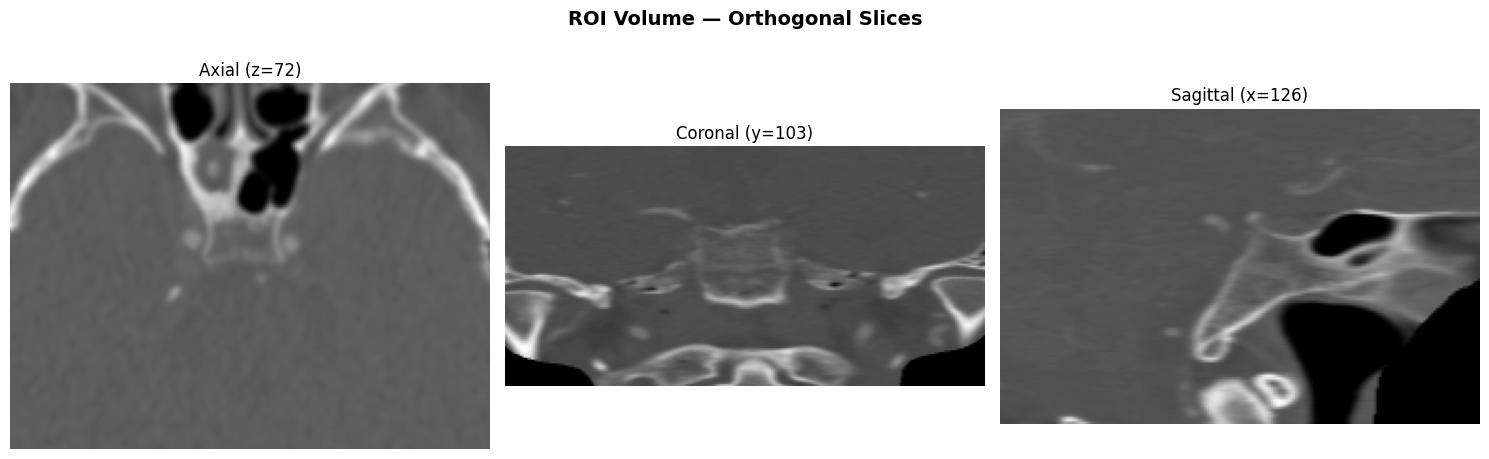

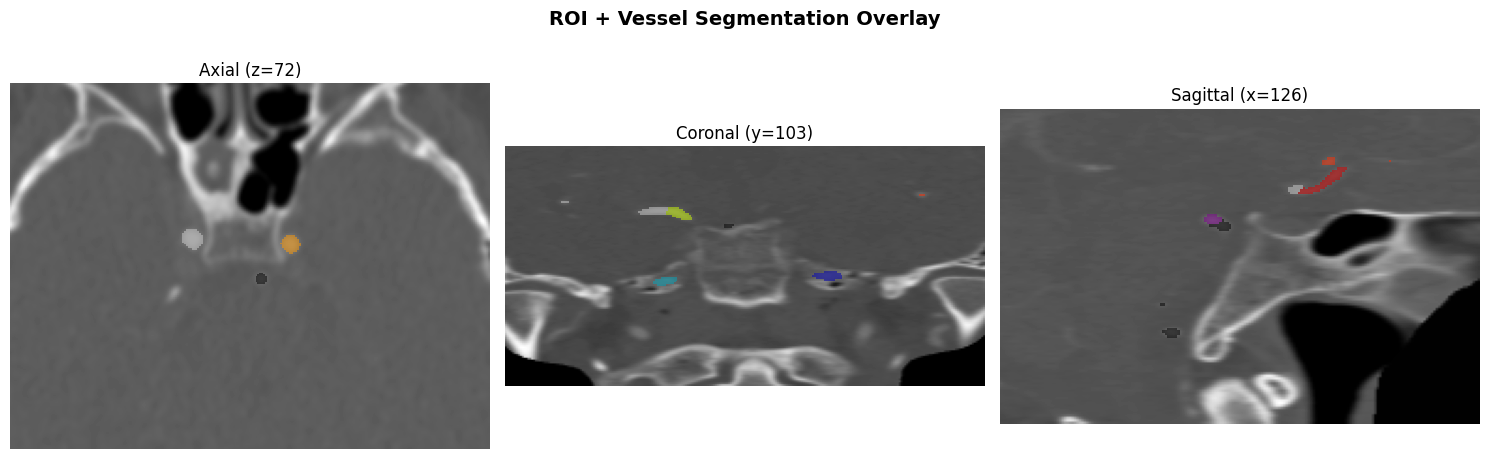

In [13]:
import matplotlib.pyplot as plt
import numpy.ma as ma

# Prepare 3D volumes
if roi_np.ndim == 4:
    roi_vol = roi_np[0]
elif roi_np.ndim == 3:
    roi_vol = roi_np
else:
    roi_vol = np.squeeze(roi_np)

# Find center of vessel segmentation
seg_coords = np.argwhere(seg_vol > 0)
if seg_coords.size > 0:
    center = np.clip(
        np.round(seg_coords.mean(axis=0)).astype(int),
        0, np.array(seg_vol.shape) - 1
    )
else:
    center = np.array(seg_vol.shape) // 2

cz, cy, cx = int(center[0]), int(center[1]), int(center[2])

# ── Plot 1: ROI volume only ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('ROI Volume — Orthogonal Slices', fontsize=14, fontweight='bold')

views = [
    ('Axial (z=%d)' % cz,     roi_vol[cz, :, :]),
    ('Coronal (y=%d)' % cy,   roi_vol[:, cy, :]),
    ('Sagittal (x=%d)' % cx,  roi_vol[:, :, cx]),
]
for ax, (title, slc) in zip(axes, views):
    ax.imshow(np.nan_to_num(slc), cmap='gray', origin='lower')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# ── Plot 2: ROI + segmentation overlay ───────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle('ROI + Vessel Segmentation Overlay', fontsize=14, fontweight='bold')

overlay_views = [
    ('Axial (z=%d)' % cz,    roi_vol[cz, :, :],   seg_vol[cz, :, :]),
    ('Coronal (y=%d)' % cy,  roi_vol[:, cy, :],    seg_vol[:, cy, :]),
    ('Sagittal (x=%d)' % cx, roi_vol[:, :, cx],    seg_vol[:, :, cx]),
]
for ax, (title, img_slc, seg_slc) in zip(axes2, overlay_views):
    img_slc = np.nan_to_num(img_slc)
    ax.imshow(img_slc, cmap='gray', origin='lower')
    seg_mask = seg_slc > 0
    if seg_mask.any():
        overlay = ma.masked_where(~seg_mask, seg_slc)
        ax.imshow(overlay, cmap='nipy_spectral', origin='lower',
                  alpha=0.5, interpolation='nearest')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 12. Multi-Slice Gallery

Show multiple axial slices evenly spaced through the ROI volume for a comprehensive view of the extracted region.

Slice with most vessels: z=93 (901 vessel voxels)


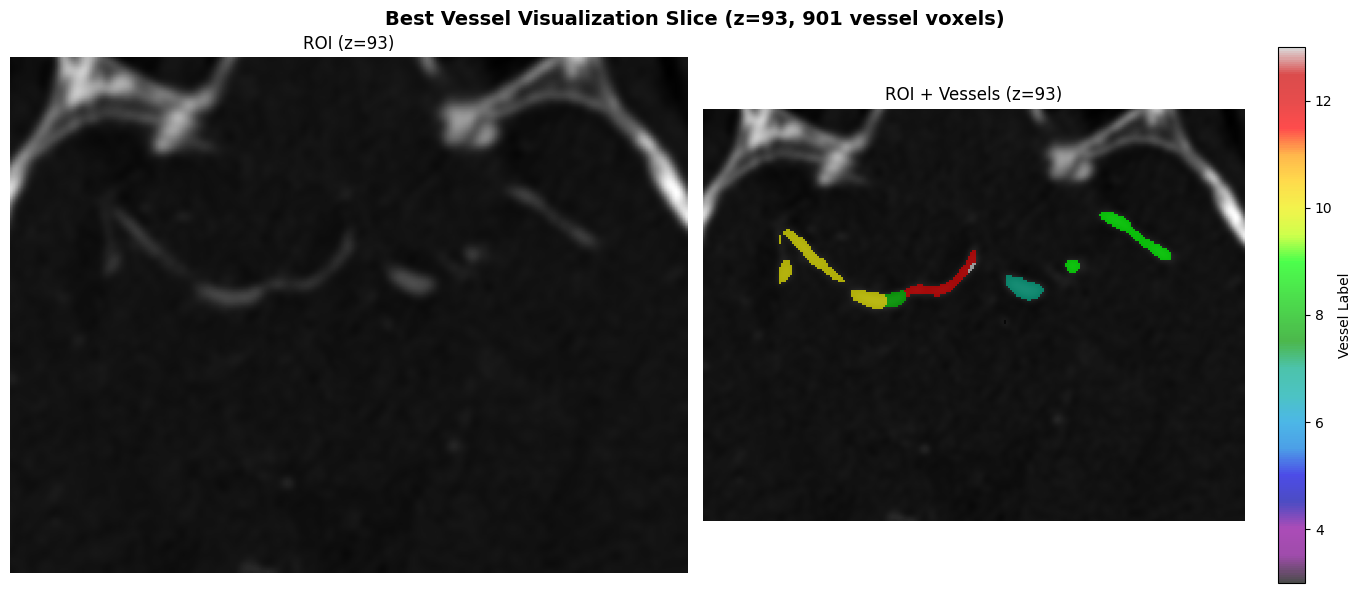


Vessel labels in best slice: [3, 7, 8, 9, 10, 12, 13]


In [14]:
n_slices = 12
z_depth = roi_vol.shape[0]

# Find the slice with the maximum number of vessel voxels
vessel_counts = np.array([np.count_nonzero(seg_vol[z, :, :]) for z in range(z_depth)])
best_slice = np.argmax(vessel_counts)

print(f"Slice with most vessels: z={best_slice} ({vessel_counts[best_slice]} vessel voxels)")

# Display the single best slice
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Best Vessel Visualization Slice (z={best_slice}, {vessel_counts[best_slice]} vessel voxels)',
             fontsize=14, fontweight='bold')

# Left: ROI only
ax = axes[0]
img_slc = np.nan_to_num(roi_vol[best_slice, :, :])
ax.imshow(img_slc, cmap='gray', origin='lower')
ax.set_title(f'ROI (z={best_slice})', fontsize=12)
ax.axis('off')

# Right: ROI + Segmentation overlay
ax = axes[1]
img_slc = np.nan_to_num(roi_vol[best_slice, :, :])
ax.imshow(img_slc, cmap='gray', origin='lower')
seg_slc = seg_vol[best_slice, :, :]
seg_mask = seg_slc > 0
if seg_mask.any():
    overlay = ma.masked_where(~seg_mask, seg_slc)
    im = ax.imshow(overlay, cmap='nipy_spectral', origin='lower',
                   alpha=0.7, interpolation='nearest')
    # Add colorbar to show vessel labels
    cbar = plt.colorbar(im, ax=ax, label='Vessel Label')
ax.set_title(f'ROI + Vessels (z={best_slice})', fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.show()

# Print vessel statistics for this slice
print(f"\nVessel labels in best slice: {np.unique(seg_slc[seg_mask]).astype(int).tolist()}")


## 13. Pipeline Summary & Metadata Report

Final consolidated report with all relevant metadata, matching the information that would be logged by the competition submission pipeline.

In [15]:
print(f"{'='*70}")
print(f"📋 COMPLETE PIPELINE SUMMARY")
print(f"{'='*70}")
print()
print(f"── Input ──────────────────────────────────────────────────────")
print(f"  File              : {os.path.basename(NIFTI_INPUT_PATH)}")
print(f"  Input volume shape: {image.shape}  (C, Z, Y, X)")
print(f"  Voxel spacing     : z={spacing[0]:.4f}, y={spacing[1]:.4f}, x={spacing[2]:.4f} mm")
print(f"  Physical dims     : {image.shape[1]*spacing[0]:.1f} × {image.shape[2]*spacing[1]:.1f} × {image.shape[3]*spacing[2]:.1f} mm")
print()
print(f"── Models ─────────────────────────────────────────────────────")
print(f"  Primary model     : {os.path.basename(VESSEL_NNUNET_MODEL_DIR)}")
print(f"  Sparse model      : {os.path.basename(VESSEL_NNUNET_SPARSE_MODEL_DIR)}")
print(f"  Extra model       : {os.path.basename(VESSEL_ADDITIONAL_DENSE_DIR)}")
print(f"  Folds             : {VESSEL_FOLDS}")
print(f"  Device            : {DEVICE}")
print()
print(f"── Segmentation Output ────────────────────────────────────────")
print(f"  Seg shape         : {seg_np.shape}")
print(f"  Unique labels     : {np.unique(seg_np).tolist()}")
print(f"  Vessel voxels     : {np.count_nonzero(seg_np):,}")
print()
print(f"── ROI Volume Output ──────────────────────────────────────────")
print(f"  ROI shape         : {roi_np.shape}  (C, Z, Y, X)")
if roi_np.ndim == 4:
    print(f"  ROI spatial       : {roi_np.shape[1]} × {roi_np.shape[2]} × {roi_np.shape[3]}")
print(f"  Value range       : [{roi_np.min():.4f}, {roi_np.max():.4f}]")
print(f"  Mean / Std        : {roi_np.mean():.4f} / {roi_np.std():.4f}")
print()
print(f"── Union Mask ─────────────────────────────────────────────────")
print(f"  Vessel voxels     : {union_mask.sum():,}")
print(f"  Volume fraction   : {union_mask.sum() / union_mask.size * 100:.2f}%")
print()
print(f"── Pipeline Stages ────────────────────────────────────────────")
print(f"  Stages completed  : {' → '.join(s.value for s in vessel_out.stage_history)}")
print(f"  Full pipeline     : {vessel_out.is_full}")
print()
print(f"── Timing ─────────────────────────────────────────────────────")
print(f"  NIfTI load        : {load_time:.2f}s")
print(f"  Predictor init    : {init_time:.2f}s")
print(f"  Pipeline run      : {pipeline_time:.2f}s")
print(f"  Total wall time   : {load_time + init_time + pipeline_time:.2f}s")
print(f"{'='*70}")
print()
print("✅ Vessel segmentation and ROI extraction complete!")
print("   The ROI volume and segmentation mask are ready for downstream")
print("   ROI classification (aneurysm detection).")

📋 COMPLETE PIPELINE SUMMARY

── Input ──────────────────────────────────────────────────────
  File              : 701.nii.gz
  Input volume shape: (1, 276, 512, 512)  (C, Z, Y, X)
  Voxel spacing     : z=0.4000, y=0.4395, x=0.4395 mm
  Physical dims     : 110.4 × 225.0 × 225.0 mm

── Models ─────────────────────────────────────────────────────
  Primary model     : nnunet-da3-sklr-ep800
  Sparse model      : nnunet-vessel-grouping-da7
  Extra model       : nnunet-da6-sklr-w3-tv07
  Folds             : ['all']
  Device            : cuda:0

── Segmentation Output ────────────────────────────────────────
  Seg shape         : (128, 195, 256)
  Unique labels     : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
  Vessel voxels     : 24,890

── ROI Volume Output ──────────────────────────────────────────
  ROI shape         : (1, 128, 195, 256)  (C, Z, Y, X)
  ROI spatial       : 128 × 195 × 256
  Value range       : [-1.9971, 5.8125]
  Mean / Std        : 0.0002 / inf

── Union Mask ──────

## 14. Cleanup

Free GPU memory after inference.

In [16]:
# Free GPU memory
del predictor
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved  = torch.cuda.memory_reserved() / 1024**2
    print(f"GPU memory after cleanup: {allocated:.0f} MB allocated, {reserved:.0f} MB reserved")
else:
    print("Cleanup complete.")

GPU memory after cleanup: 130 MB allocated, 752 MB reserved
